# 05 Driving Postprocess Staged Sweep - finetune_v1

04 노트북에서는 fine-tuned CLRKDNet이 출력한 lane 후보를 주행 중심선으로 바꾸는 기본 로직을 만들었다.  
이번 노트북의 목적은 그 후처리 로직의 조절 가능한 축을 넓게 확인하되, 조합 폭발을 피하면서 실제 Pi 포팅 후보를 좁히는 것이다.

중요한 점은 여기서 찾는 값이 모델 가중치가 아니라는 것이다.  
ONNX 모델은 lane 후보 좌표들을 내고, 이 노트북은 그 후보들 중 어떤 lane을 고르고, 어떤 지점의 중심을 보고, 한쪽 lane만 보일 때 어떻게 보정할지를 결정한다.

전체 전수조사는 pseudo GT에 과적합된 1등 조합을 찾을 위험이 있고, 계산량도 지나치게 커진다.  
따라서 이 노트북은 아래 구조로 진행한다.

1. detector 후보 생성 설정은 전체 holdout에서 넓게 확인함.
2. driving postprocess는 scene별 균등 샘플에서 축을 넓게 훑음.
3. 상위 후보 주변만 전체 holdout에서 다시 평가함.
4. 최종 후보는 숫자와 overlay를 함께 보고 결정함.

## 1. Sweep 축 분류와 staged 전략

후처리 설정은 크게 세 층으로 나뉜다.

첫째, detector 후보 생성 설정이다.  
`conf_threshold`, `nms_thres`, `max_lanes`는 CLRKDNet head의 공식 `get_lanes()` 후처리로 몇 개의 lane 후보를 꺼낼지 결정한다.

둘째, 단일 프레임 driving postprocess 설정이다.  
lane 후보 중 어느 것을 좌/우 차선으로 볼지, 어느 y 위치를 lookahead로 볼지, 한쪽 lane만 보일 때 중심을 얼마나 offset할지 결정한다.

셋째, temporal smoothing 설정이다.  
프레임별 중심선이 흔들릴 때 이전 중심을 얼마나 섞을지, 잠깐 lane을 놓쳤을 때 몇 프레임까지 hold할지 결정한다.

전수조사를 하지 않는 이유는 두 가지다.

- holdout은 연속 주행 자동 캡처라 인접 프레임이 비슷함.
- pseudo GT 자체가 완벽한 정답이 아니므로, 전수조사 1등보다 안정적인 후보군이 더 중요함.

그래서 postprocess는 `axis coverage + random broad search -> full holdout finalist search -> temporal search` 순서로 줄인다.

In [28]:
from pathlib import Path
import sys
import os
import json
import pickle
import itertools
from dataclasses import dataclass, asdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '06_lane_model_finetuning'
OUTPUT_ROOT = EXP_ROOT / 'colab_outputs' / 'finetune_v1'
FULL_ROOT = OUTPUT_ROOT / 'MapLane_Field1Field2_full'

PREV_REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '03_official_lane_detector_postprocess_review_finetune_v1'
FORWARD_CACHE_PATH = PREV_REVIEW_ROOT / 'finetuned_forward_cache_full_holdout.pkl'

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '05_driving_postprocess_sweep'
OVERLAY_DIR = REVIEW_ROOT / 'overlays'
TABLE_DIR = REVIEW_ROOT / 'tables'
CACHE_DIR = REVIEW_ROOT / 'cache'
for p in [REVIEW_ROOT, OVERLAY_DIR, TABLE_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RAW_W = 1296
RAW_H = 972
CUT_HEIGHT = 445
VISIBLE_H = RAW_H - CUT_HEIGHT
IMAGE_CENTER_X = RAW_W / 2

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 빠른 구조 확인용. True면 전체 forward cache 중 앞쪽 일부만 사용한다.
# 실제 후보 결정은 False 상태가 맞다.
QUICK_MODE = False
QUICK_LIMIT = 120

# scene별 시간순 균등 샘플 수.
# 자동 캡처 데이터는 연속 프레임이 비슷하므로 random보다 evenly-spaced sampling이 더 적합하다.
COARSE_SAMPLE_PER_SCENE = 120
COARSE_SAMPLE_MIN_PER_SCENE = 40

# detector는 조합 수가 작으므로 전체 holdout에서 본다.
TOP_DETECTOR_COUNT = 8

# coarse 결과는 이미 저장돼 있으면 재사용한다.
FORCE_COARSE_REBUILD = False

# full holdout에서는 coarse 상위 후보만 검증한다.
# 현재 PC 속도 기준 120개면 대략 10~20분 범위로 보는 것이 현실적이다.
FULL_EVAL_TOP_COARSE_CONFIGS = 120

TOP_POSTPROCESS_COUNT_FOR_DETAIL = 8
TOP_TEMPORAL_BASE_CONFIGS = 5

print('FORWARD_CACHE_PATH:', FORWARD_CACHE_PATH, 'exists=', FORWARD_CACHE_PATH.exists())
assert FORWARD_CACHE_PATH.exists(), '먼저 03 노트북에서 full holdout forward cache를 만들어야 함.'

FORWARD_CACHE_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\03_official_lane_detector_postprocess_review_finetune_v1\finetuned_forward_cache_full_holdout.pkl exists= True


## 2. 유틸리티와 CLRKDNet code snapshot 로딩

이번 노트북도 03/04와 동일하게 Colab full fine-tuning 결과 안의 `code/` snapshot을 import함.

이유:

- raw output을 lane 좌표로 바꾸는 `get_lanes()`는 repo 코드에 의존함.
- 학습 당시 code snapshot과 inference code가 달라지면 실험이 꼬임.

In [29]:
def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def path_exists(path):
    return Path(win_long_path(path)).exists()


def read_text_any(path):
    path = Path(path)
    for enc in ['utf-8', 'utf-8-sig', 'cp949']:
        try:
            return path.read_text(encoding=enc)
        except UnicodeDecodeError:
            continue
    return path.read_text(encoding='utf-8', errors='replace')


def cv2_imread_color(path):
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def cv2_imwrite(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or '.png'
    ok, buf = cv2.imencode(ext, image)
    if not ok:
        raise RuntimeError(f'failed to encode image: {path}')
    buf.tofile(win_long_path(path))


def find_single_run_dir(root: Path) -> Path:
    runs = sorted([p for p in root.iterdir() if p.is_dir()])
    if len(runs) != 1:
        print('run dirs:')
        for p in runs:
            print(' -', p)
        raise RuntimeError(f'expected exactly one run dir under {root}, got {len(runs)}')
    return runs[0]


FULL_RUN = find_single_run_dir(FULL_ROOT)
CODE_DIR = FULL_RUN / 'code'
CONFIG_PATH = FULL_RUN / 'config.py'
FINETUNED_PTH = FULL_RUN / 'ckpt' / 'best.pth'

for name, path in [
    ('FULL_RUN', FULL_RUN),
    ('CODE_DIR', CODE_DIR),
    ('CONFIG_PATH', CONFIG_PATH),
    ('FINETUNED_PTH', FINETUNED_PTH),
]:
    print(f'{name}: {path} exists={path_exists(path)}')
    assert path_exists(path), path

FULL_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8 exists=True
CODE_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\code exists=True
CONFIG_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\config.py exists=True
FINETUNED_PTH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\best.pth exists=True


In [30]:
import torch

for module_name in list(sys.modules):
    if module_name == 'clrkd' or module_name.startswith('clrkd.') or module_name == 'mmcv' or module_name.startswith('mmcv.'):
        del sys.modules[module_name]

if str(CODE_DIR) in sys.path:
    sys.path.remove(str(CODE_DIR))
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net


def load_config_windows_safe(config_path: Path):
    text = read_text_any(config_path)
    namespace = {}
    exec(compile(text, str(config_path), 'exec'), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith('__')}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))


def torch_load(path: Path):
    try:
        return torch.load(win_long_path(path), map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(win_long_path(path), map_location=DEVICE)


def clean_state_dict(raw_state):
    cleaned = {}
    for k, v in raw_state.items():
        if k.startswith('module.'):
            k = k[len('module.'):]
        cleaned[k] = v
    return cleaned


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('DEVICE:', DEVICE)

cfg = load_config_windows_safe(CONFIG_PATH)
model = build_net(cfg)
ckpt = torch_load(FINETUNED_PTH)
raw_state = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
state = clean_state_dict(raw_state)
missing, unexpected = model.load_state_dict(state, strict=False)
model = model.to(DEVICE).eval()

print('missing keys:', len(missing))
print('unexpected keys:', len(unexpected))

torch: 2.11.0+cpu
DEVICE: cpu
missing keys: 0
unexpected keys: 0


## 3. 03 forward cache 읽기

cache에는 이미 전체 holdout usable 722장의 model raw output이 들어 있음.  
이번 노트북에서는 model forward를 다시 하지 않고, detector/postprocess만 바꿈.

In [31]:
with open(win_long_path(FORWARD_CACHE_PATH), 'rb') as f:
    forward_cache = pickle.load(f)

all_samples = forward_cache['samples']
if QUICK_MODE:
    samples = all_samples[:QUICK_LIMIT]
else:
    samples = all_samples

ALL_SAMPLE_INDICES = list(range(len(samples)))


def evenly_spaced_scene_indices(samples, per_scene=120, min_per_scene=40):
    indices = []
    sample_df = pd.DataFrame([
        {'pos': i, 'scene': s['scene'], 'rel': s['rel'], 'file': Path(s['rel']).name}
        for i, s in enumerate(samples)
    ])
    for scene, group in sample_df.sort_values(['scene', 'rel']).groupby('scene'):
        n = len(group)
        take = min(n, max(min_per_scene, min(per_scene, n)))
        if take >= n:
            chosen = group['pos'].to_numpy()
        else:
            grid = np.linspace(0, n - 1, take).round().astype(int)
            chosen = group.iloc[grid]['pos'].to_numpy()
        indices.extend(chosen.astype(int).tolist())
    return sorted(set(indices))


COARSE_SAMPLE_INDICES = evenly_spaced_scene_indices(
    samples,
    per_scene=COARSE_SAMPLE_PER_SCENE,
    min_per_scene=COARSE_SAMPLE_MIN_PER_SCENE,
)

print('all samples:', len(all_samples))
print('active samples:', len(samples))
print('coarse sample frames:', len(COARSE_SAMPLE_INDICES))
print('scene counts - full:')
print(pd.Series([s['scene'] for s in samples]).value_counts())
print('\nscene counts - coarse:')
print(pd.Series([samples[i]['scene'] for i in COARSE_SAMPLE_INDICES]).value_counts())
print('first sample keys:', samples[0].keys())

all samples: 722
active samples: 722
coarse sample frames: 240
scene counts - full:
field1_sign_background       413
field2_traffic_background    309
Name: count, dtype: int64

scene counts - coarse:
field1_sign_background       120
field2_traffic_background    120
Name: count, dtype: int64
first sample keys: dict_keys(['index', 'scene', 'rel', 'img_path', 'lines_path', 'gt', 'raw_output'])


## 4. Detector 설정 sweep

Detector 설정은 모델 raw output에서 lane 후보를 몇 개 살릴지 결정함.

```text
conf_threshold: 낮을수록 후보를 많이 살림
nms_thres: 중복 lane 제거 기준
max_lanes: 최종 후보 최대 개수
```

04 결과상 driving center 기준으로는 `max_lanes=4`가 좋아 보였지만, 이번 노트북에서는 `2, 3, 4`를 모두 비교함.

디코딩 결과는 `decoded_lanes_cache.pkl`에 저장함.  
같은 detector 설정으로 다시 실행할 때는 공식 `get_lanes()`를 반복 호출하지 않음.

In [32]:
@dataclass(frozen=True)
class DetectorSetting:
    conf_threshold: float
    nms_thres: int
    max_lanes: int

    @property
    def name(self):
        return f'conf{self.conf_threshold:.2f}_nms{self.nms_thres}_max{self.max_lanes}'


DETECTOR_CONF_SWEEP = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
DETECTOR_NMS_SWEEP = [30, 50, 70]
DETECTOR_MAX_LANES_SWEEP = [2, 3, 4]

DETECTOR_SETTINGS = [
    DetectorSetting(conf, nms, max_lanes)
    for conf in DETECTOR_CONF_SWEEP
    for nms in DETECTOR_NMS_SWEEP
    for max_lanes in DETECTOR_MAX_LANES_SWEEP
]

print('detector settings:', len(DETECTOR_SETTINGS))
print([s.name for s in DETECTOR_SETTINGS[:10]], '...')

detector settings: 54
['conf0.15_nms30_max2', 'conf0.15_nms30_max3', 'conf0.15_nms30_max4', 'conf0.15_nms50_max2', 'conf0.15_nms50_max3', 'conf0.15_nms50_max4', 'conf0.15_nms70_max2', 'conf0.15_nms70_max3', 'conf0.15_nms70_max4', 'conf0.20_nms30_max2'] ...


In [33]:
def apply_detector_setting(setting: DetectorSetting):
    model.heads.cfg.test_parameters.conf_threshold = float(setting.conf_threshold)
    model.heads.cfg.test_parameters.nms_thres = int(setting.nms_thres)
    model.heads.cfg.max_lanes = int(setting.max_lanes)


def lane_to_serial(lane):
    pts = lane.to_array(cfg)
    if pts is None or len(pts) < 2:
        return None
    score = lane.metadata.get('conf', None)
    try:
        score = float(score.detach().cpu()) if hasattr(score, 'detach') else float(score)
    except Exception:
        score = None
    return {'points': pts.tolist(), 'score': score}


def decode_raw_output(raw_output_cpu, setting: DetectorSetting):
    apply_detector_setting(setting)
    output = raw_output_cpu.clone().to(DEVICE)
    with torch.no_grad():
        lanes = model.heads.get_lanes(output, as_lanes=True)[0]
    serial = []
    for lane in lanes:
        item = lane_to_serial(lane)
        if item is not None:
            serial.append(item)
    return serial


DECODE_CACHE_PATH = CACHE_DIR / f'decoded_lanes_cache_{"quick" if QUICK_MODE else "full"}_{len(samples)}.pkl'


def build_or_load_decode_cache(force=False):
    settings_meta = {
        'sample_rels': [s['rel'] for s in samples],
        'detector_settings': [asdict(s) for s in DETECTOR_SETTINGS],
        'checkpoint': str(FINETUNED_PTH),
    }
    if path_exists(DECODE_CACHE_PATH) and not force:
        with open(win_long_path(DECODE_CACHE_PATH), 'rb') as f:
            cache = pickle.load(f)
        if cache.get('settings_meta') == settings_meta:
            print('loaded decode cache:', DECODE_CACHE_PATH)
            return cache['decoded']
        print('decode cache exists but settings changed. rebuilding.')

    decoded = {}
    total = len(DETECTOR_SETTINGS)
    for si, setting in enumerate(DETECTOR_SETTINGS, start=1):
        print(f'[{si:02d}/{total}] decode {setting.name}')
        lanes_for_setting = []
        for sample in samples:
            lanes_for_setting.append(decode_raw_output(sample['raw_output'], setting))
        decoded[setting.name] = lanes_for_setting

    with open(win_long_path(DECODE_CACHE_PATH), 'wb') as f:
        pickle.dump({'settings_meta': settings_meta, 'decoded': decoded}, f)
    print('saved decode cache:', DECODE_CACHE_PATH)
    return decoded


decoded_cache = build_or_load_decode_cache(force=False)
print('decoded settings:', len(decoded_cache))
print('first decoded counts:', {k: len(v[0]) for k, v in list(decoded_cache.items())[:3]})

loaded decode cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\cache\decoded_lanes_cache_full_722.pkl
decoded settings: 54
first decoded counts: {'conf0.15_nms30_max2': 2, 'conf0.15_nms30_max3': 3, 'conf0.15_nms30_max4': 4}


## 5. 좌표 보간과 profile별 lane width 추정

Lookahead 위치가 바뀌면 차로 폭도 달라짐.  
카메라 원근 때문에 이미지 아래쪽에서는 lane 간격이 넓고, 위쪽에서는 좁아지기 때문임.

따라서 이번 노트북은 profile별 pseudo GT lane width median을 계산함.

In [34]:
def lane_points(lane_item):
    pts = np.array(lane_item['points'], dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 2:
        return np.empty((0, 2), dtype=np.float32)
    df = (
        pd.DataFrame(pts, columns=['x', 'y'])
        .groupby('y', as_index=False)['x']
        .mean()
        .sort_values('y')
    )
    return df[['x', 'y']].to_numpy(dtype=np.float32)


def y_from_ratio(ratio):
    return CUT_HEIGHT + VISIBLE_H * float(ratio)


def interp_x_at_y(pts, y):
    if len(pts) < 2:
        return np.nan
    xs = pts[:, 0]
    ys = pts[:, 1]
    order = np.argsort(ys)
    ys = ys[order]
    xs = xs[order]
    if y < ys.min() or y > ys.max():
        return np.nan
    return float(np.interp(y, ys, xs))


def nearest_x_to_y(pts, y):
    if len(pts) == 0:
        return np.nan, np.inf
    idx = int(np.argmin(np.abs(pts[:, 1] - y)))
    return float(pts[idx, 0]), float(abs(pts[idx, 1] - y))


@dataclass(frozen=True)
class LookaheadProfile:
    name: str
    ratios: tuple
    weights: tuple
    primary_ratio: float

    @property
    def ys(self):
        return tuple(y_from_ratio(r) for r in self.ratios)


LOOKAHEAD_PROFILES = [
    LookaheadProfile('single_070', (0.70,), (1.0,), 0.70),
    LookaheadProfile('single_075', (0.75,), (1.0,), 0.75),
    LookaheadProfile('single_080', (0.80,), (1.0,), 0.80),
    LookaheadProfile('single_085', (0.85,), (1.0,), 0.85),
    LookaheadProfile('multi_70_78_86', (0.70, 0.78, 0.86), (0.25, 0.45, 0.30), 0.78),
    LookaheadProfile('multi_74_82_90', (0.74, 0.82, 0.90), (0.25, 0.45, 0.30), 0.82),
]


def profile_by_name(name):
    return {p.name: p for p in LOOKAHEAD_PROFILES}[name]


def lane_xs_for_profile(pts, profile: LookaheadProfile):
    xs = []
    y_dists = []
    for y in profile.ys:
        x = interp_x_at_y(pts, y)
        y_dist = 0.0
        if not np.isfinite(x):
            x, y_dist = nearest_x_to_y(pts, y)
        xs.append(x)
        y_dists.append(y_dist)
    return np.array(xs, dtype=np.float32), np.array(y_dists, dtype=np.float32)


def weighted_x(xs, weights):
    xs = np.asarray(xs, dtype=np.float32)
    weights = np.asarray(weights, dtype=np.float32)
    valid = np.isfinite(xs)
    if valid.sum() == 0:
        return np.nan
    w = weights[valid]
    w = w / w.sum()
    return float(np.sum(xs[valid] * w))


def estimate_width_for_profile(profile):
    widths = []
    for sample in samples:
        gt_pts = [lane_points(l) for l in sample['gt']]
        feats = []
        for pts in gt_pts:
            if len(pts) < 2:
                continue
            xs, y_dists = lane_xs_for_profile(pts, profile)
            x = weighted_x(xs, profile.weights)
            if not np.isfinite(x):
                continue
            side = 'left' if x < IMAGE_CENTER_X else 'right'
            feats.append({'x': x, 'side': side})
        lefts = [f for f in feats if f['side'] == 'left']
        rights = [f for f in feats if f['side'] == 'right']
        if not lefts or not rights:
            continue
        left = sorted(lefts, key=lambda f: f['x'], reverse=True)[0]
        right = sorted(rights, key=lambda f: f['x'])[0]
        gap = right['x'] - left['x']
        if 80 <= gap <= 1200:
            widths.append(gap)
    return float(np.nanmedian(np.array(widths, dtype=np.float32))) if widths else np.nan


PROFILE_WIDTHS = {p.name: estimate_width_for_profile(p) for p in LOOKAHEAD_PROFILES}
pd.DataFrame([{'profile': k, 'expected_width_px': v} for k, v in PROFILE_WIDTHS.items()])

,profile,expected_width_px
0,single_070,835.896545
1,single_075,877.191162
2,single_080,918.461914
3,single_085,960.623901
4,multi_70_78_86,905.144348
5,multi_74_82_90,940.437073


## 6. Driving postprocess 설정 구조

아래 `PostprocessConfig`가 Pi 스크립트에서 나중에 수정 가능한 설정들의 원형임.

즉, 이 노트북의 sweep 결과는 나중에 아래 값들을 Pi 코드의 config로 옮기는 근거가 됨.

In [35]:
@dataclass(frozen=True)
class PostprocessConfig:
    detector_name: str
    lookahead_profile: str
    min_lane_points: int
    min_y_span: float
    max_y_distance: float
    duplicate_x_px: float
    pair_policy: str
    gap_min_scale: float
    gap_max_scale: float
    one_lane_offset_scale: float
    one_lane_policy: str
    center_policy: str

    @property
    def name(self):
        parts = [
            self.detector_name,
            self.lookahead_profile,
            f'p{self.min_lane_points}',
            f'y{int(self.min_y_span)}',
            f'd{int(self.max_y_distance)}',
            f'dup{int(self.duplicate_x_px)}',
            self.pair_policy,
            f'g{self.gap_min_scale:.2f}-{self.gap_max_scale:.2f}',
            f'one{self.one_lane_offset_scale:.2f}',
            self.one_lane_policy,
            self.center_policy,
        ]
        return '__'.join(parts)


def config_to_row(cfg_obj: PostprocessConfig):
    return asdict(cfg_obj) | {'config_name': cfg_obj.name}

## 7. Driving postprocess 구현

여기부터가 실제로 Pi 주행 코드에 옮겨질 수 있는 핵심 로직임.

구조:

```text
lanes
-> feature 계산
-> duplicate 제거
-> left/right pair 선택
-> center 계산
-> one-lane fallback
```

In [36]:
def lane_feature(lane_item, profile: LookaheadProfile, cfg_obj: PostprocessConfig):
    pts = lane_points(lane_item)
    if len(pts) < 2:
        return None
    y_min, y_max = float(pts[:, 1].min()), float(pts[:, 1].max())
    y_span = y_max - y_min
    if len(pts) < cfg_obj.min_lane_points or y_span < cfg_obj.min_y_span:
        return None

    xs, y_dists = lane_xs_for_profile(pts, profile)
    x_weighted = weighted_x(xs, profile.weights)
    primary_y = y_from_ratio(profile.primary_ratio)
    x_primary = interp_x_at_y(pts, primary_y)
    primary_dist = 0.0
    if not np.isfinite(x_primary):
        x_primary, primary_dist = nearest_x_to_y(pts, primary_y)

    if not np.isfinite(x_weighted) or not np.isfinite(x_primary):
        return None
    if float(np.nanmin(y_dists)) > cfg_obj.max_y_distance and primary_dist > cfg_obj.max_y_distance:
        return None

    side = 'left' if x_primary < IMAGE_CENTER_X else 'right'
    score = lane_item.get('score', None)
    # score는 공식 softmax 확률이 아니라 metadata raw 값일 수 있으므로 보조정보로만 둠.
    quality = y_span + len(pts) * 3 - primary_dist * 0.6 - float(np.nanmean(y_dists)) * 0.3

    return {
        'points': pts,
        'score': score,
        'xs': xs,
        'x_weighted': float(x_weighted),
        'x_primary': float(x_primary),
        'primary_y_distance': float(primary_dist),
        'side': side,
        'y_min': y_min,
        'y_max': y_max,
        'y_span': y_span,
        'num_points': int(len(pts)),
        'quality': float(quality),
    }


def suppress_duplicates(features, duplicate_x_px):
    if duplicate_x_px <= 0:
        return features
    kept = []
    # quality가 높은 후보부터 살리고, lookahead x가 너무 가까운 후보는 duplicate로 제거.
    for feat in sorted(features, key=lambda f: f['quality'], reverse=True):
        if all(abs(feat['x_primary'] - other['x_primary']) > duplicate_x_px for other in kept):
            kept.append(feat)
    return kept


def compute_pair_score(left, right, expected_width, cfg_obj: PostprocessConfig):
    gap = right['x_primary'] - left['x_primary']
    gap_error = abs(gap - expected_width) / max(expected_width, 1.0)
    center = (left['x_primary'] + right['x_primary']) / 2
    center_bias = abs(center - IMAGE_CENTER_X) / (RAW_W / 2)
    quality = (left['quality'] + right['quality']) / 1000.0

    if cfg_obj.pair_policy == 'nearest_to_center':
        return -center_bias
    if cfg_obj.pair_policy == 'quality_first':
        return quality - 0.25 * gap_error
    if cfg_obj.pair_policy == 'gap_prior':
        return -gap_error + 0.15 * quality
    if cfg_obj.pair_policy == 'balanced':
        return -0.65 * gap_error - 0.35 * center_bias + 0.20 * quality
    raise ValueError(cfg_obj.pair_policy)


def select_pair(features, expected_width, cfg_obj: PostprocessConfig):
    lefts = [f for f in features if f['side'] == 'left']
    rights = [f for f in features if f['side'] == 'right']

    if not lefts and not rights:
        return None, None, 'no_features'

    gap_min = expected_width * cfg_obj.gap_min_scale
    gap_max = expected_width * cfg_obj.gap_max_scale

    pair_candidates = []
    for left in lefts:
        for right in rights:
            gap = right['x_primary'] - left['x_primary']
            if gap_min <= gap <= gap_max:
                pair_candidates.append((compute_pair_score(left, right, expected_width, cfg_obj), left, right, gap))

    if pair_candidates:
        pair_candidates.sort(key=lambda x: x[0], reverse=True)
        _, left, right, _ = pair_candidates[0]
        return left, right, 'valid_pair'

    # 유효 pair가 없으면 one-lane fallback을 위해 한쪽 후보를 선택.
    def choose_one(cands):
        if not cands:
            return None
        if cfg_obj.one_lane_policy == 'center_nearest':
            return sorted(cands, key=lambda f: abs(f['x_primary'] - IMAGE_CENTER_X))[0]
        if cfg_obj.one_lane_policy == 'quality_first':
            return sorted(cands, key=lambda f: f['quality'], reverse=True)[0]
        if cfg_obj.one_lane_policy == 'bottom_quality':
            return sorted(cands, key=lambda f: (f['y_span'], f['quality']), reverse=True)[0]
        raise ValueError(cfg_obj.one_lane_policy)

    left = choose_one(lefts)
    right = choose_one(rights)
    if left is not None and right is not None:
        # gap이 말이 안 되는 pair였으므로 더 신뢰할 수 있는 한쪽만 사용.
        if left['quality'] >= right['quality']:
            return left, None, 'bad_pair_left_fallback'
        return None, right, 'bad_pair_right_fallback'
    return left, right, 'one_side'


def center_from_pair(left, right, expected_width, profile: LookaheadProfile, cfg_obj: PostprocessConfig):
    if left is not None and right is not None:
        if cfg_obj.center_policy == 'primary':
            return (left['x_primary'] + right['x_primary']) / 2
        if cfg_obj.center_policy == 'weighted_profile':
            centers = (left['xs'] + right['xs']) / 2
            return weighted_x(centers, profile.weights)
        raise ValueError(cfg_obj.center_policy)

    offset = expected_width * cfg_obj.one_lane_offset_scale
    if left is not None:
        x = left['x_weighted'] if cfg_obj.center_policy == 'weighted_profile' else left['x_primary']
        return x + offset
    if right is not None:
        x = right['x_weighted'] if cfg_obj.center_policy == 'weighted_profile' else right['x_primary']
        return x - offset
    return np.nan


def driving_postprocess(lanes, cfg_obj: PostprocessConfig, return_debug=False):
    profile = profile_by_name(cfg_obj.lookahead_profile)
    expected_width = PROFILE_WIDTHS[profile.name]
    if not np.isfinite(expected_width):
        expected_width = 890.0

    features = []
    for lane in lanes:
        feat = lane_feature(lane, profile, cfg_obj)
        if feat is not None:
            features.append(feat)
    features = suppress_duplicates(features, cfg_obj.duplicate_x_px)

    left, right, pair_reason = select_pair(features, expected_width, cfg_obj)
    center_x = center_from_pair(left, right, expected_width, profile, cfg_obj)

    if left is not None and right is not None and np.isfinite(center_x):
        mode = 'both'
        confidence = 1.0
        reason = pair_reason
    elif left is not None and np.isfinite(center_x):
        mode = 'left_only'
        confidence = 0.55
        reason = pair_reason + '_left'
    elif right is not None and np.isfinite(center_x):
        mode = 'right_only'
        confidence = 0.55
        reason = pair_reason + '_right'
    else:
        mode = 'lost'
        confidence = 0.0
        reason = 'lost'

    if np.isfinite(center_x) and (center_x < -RAW_W * 0.35 or center_x > RAW_W * 1.35):
        confidence *= 0.25
        reason += '_center_outside'

    result = {
        'mode': mode,
        'center_x': float(center_x) if np.isfinite(center_x) else np.nan,
        'error_px': float(center_x - IMAGE_CENTER_X) if np.isfinite(center_x) else np.nan,
        'error_norm': float((center_x - IMAGE_CENTER_X) / (RAW_W / 2)) if np.isfinite(center_x) else np.nan,
        'confidence': float(confidence),
        'reason': reason,
        'num_features': len(features),
        'left_x': left['x_primary'] if left is not None else np.nan,
        'right_x': right['x_primary'] if right is not None else np.nan,
        'expected_width': expected_width,
    }
    if return_debug:
        result['features'] = features
        result['left'] = left
        result['right'] = right
        result['profile'] = profile
    return result

## 8. Pseudo GT target center 계산

정량 평가는 pseudo GT `.lines.txt`에서 만든 target center와 예측 center의 차이로 계산함.

주의:

- pseudo GT도 HSV 기반 자동 라벨이므로 절대 정답은 아님.
- 그래도 전체 722장에서 후처리 후보들을 상대 비교하는 기준으로는 유용함.

In [37]:
TARGET_CACHE = {}


def gt_target_center(sample, cfg_obj: PostprocessConfig):
    # GT line도 같은 lookahead/center policy로 center를 계산하되, detector setting과 duplicate 기준은 의미가 적음.
    key = (sample['index'], cfg_obj.lookahead_profile, cfg_obj.center_policy, cfg_obj.one_lane_offset_scale)
    if key in TARGET_CACHE:
        return TARGET_CACHE[key]
    target = driving_postprocess(sample['gt'], cfg_obj)
    TARGET_CACHE[key] = target
    return target


def abs_center_error(pred_result, target_result):
    px = pred_result['center_x']
    gx = target_result['center_x']
    if not np.isfinite(px) or not np.isfinite(gx):
        return np.nan
    return float(abs(px - gx))

## 9. 1차 detector sweep: 공식 `get_lanes()` 후보 생성 설정 확인

Detector 후보 생성 설정은 조합 수가 작으므로 전체 holdout에서 평가한다.  
여기서 고르는 것은 최종 주행 후처리 전체의 답이 아니라, 후속 postprocess가 사용할 lane 후보를 얼마나 넉넉하고 안정적으로 꺼내는지에 대한 1차 후보군이다.

In [38]:
BASELINE_POSTPROCESS = {
    'lookahead_profile': 'single_080',
    'min_lane_points': 6,
    'min_y_span': 70,
    'max_y_distance': 90,
    'duplicate_x_px': 35,
    'pair_policy': 'balanced',
    'gap_min_scale': 0.45,
    'gap_max_scale': 1.90,
    'one_lane_offset_scale': 0.50,
    'one_lane_policy': 'center_nearest',
    'center_policy': 'primary',
}


def evaluate_config(cfg_obj: PostprocessConfig, save_detail=False, sample_indices=None):
    if sample_indices is None:
        sample_indices = ALL_SAMPLE_INDICES

    decoded_lanes = decoded_cache[cfg_obj.detector_name]
    rows = []
    errors = []
    modes = []
    reasons = []
    confidences = []

    for idx in sample_indices:
        sample = samples[idx]
        lanes = decoded_lanes[idx]
        pred = driving_postprocess(lanes, cfg_obj)
        target = gt_target_center(sample, cfg_obj)
        err = abs_center_error(pred, target)
        if np.isfinite(err):
            errors.append(err)
        modes.append(pred['mode'])
        reasons.append(pred['reason'])
        confidences.append(pred['confidence'])
        if save_detail:
            rows.append({
                'sample_index': sample['index'],
                'sample_pos': idx,
                'scene': sample['scene'],
                'file': Path(sample['rel']).name,
                'config_name': cfg_obj.name,
                'target_mode': target['mode'],
                'target_center_x': target['center_x'],
                'pred_mode': pred['mode'],
                'pred_center_x': pred['center_x'],
                'abs_center_error_px': err,
                'confidence': pred['confidence'],
                'reason': pred['reason'],
                'num_features': pred['num_features'],
            })

    errors = np.array(errors, dtype=np.float32)
    mode_counts = pd.Series(modes).value_counts().to_dict()
    reason_counts = pd.Series(reasons).value_counts().to_dict()

    frame_count = len(sample_indices)
    lost = mode_counts.get('lost', 0)
    valid = len(errors)
    bad100 = int(np.sum(errors > 100)) if len(errors) else 0
    bad150 = int(np.sum(errors > 150)) if len(errors) else 0
    bad250 = int(np.sum(errors > 250)) if len(errors) else 0
    median = float(np.nanmedian(errors)) if len(errors) else np.nan
    p90 = float(np.nanquantile(errors, 0.90)) if len(errors) else np.nan
    p95 = float(np.nanquantile(errors, 0.95)) if len(errors) else np.nan
    mean = float(np.nanmean(errors)) if len(errors) else np.nan

    # 낮을수록 좋음.
    # median은 평상시 안정성, p90/p95는 어려운 프레임, lost/bad frame은 실제 이탈 위험을 반영한다.
    score = (
        median
        + 0.55 * p90
        + 0.20 * p95
        + 90.0 * (lost / max(frame_count, 1))
        + 30.0 * (bad100 / max(valid, 1))
        + 55.0 * (bad150 / max(valid, 1))
        + 90.0 * (bad250 / max(valid, 1))
    )

    summary = config_to_row(cfg_obj) | {
        'frames': frame_count,
        'valid_center_frames': valid,
        'lost_frames': int(lost),
        'both_frames': int(mode_counts.get('both', 0)),
        'left_only_frames': int(mode_counts.get('left_only', 0)),
        'right_only_frames': int(mode_counts.get('right_only', 0)),
        'mean_abs_center_error_px': mean,
        'median_abs_center_error_px': median,
        'p90_abs_center_error_px': p90,
        'p95_abs_center_error_px': p95,
        'bad100_frames': bad100,
        'bad150_frames': bad150,
        'bad250_frames': bad250,
        'mean_confidence': float(np.mean(confidences)) if confidences else 0.0,
        'score': float(score),
        'top_reason': max(reason_counts.items(), key=lambda x: x[1])[0] if reason_counts else '',
    }
    if save_detail:
        return summary, pd.DataFrame(rows)
    return summary


detector_rows = []
for setting in DETECTOR_SETTINGS:
    cfg_obj = PostprocessConfig(detector_name=setting.name, **BASELINE_POSTPROCESS)
    detector_rows.append(evaluate_config(cfg_obj, save_detail=False, sample_indices=ALL_SAMPLE_INDICES))

detector_df = pd.DataFrame(detector_rows).sort_values(
    ['score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'lost_frames'],
    ascending=[True, True, True, True],
).reset_index(drop=True)

DETECTOR_SWEEP_CSV = TABLE_DIR / 'stage1_detector_sweep.csv'
detector_df.to_csv(win_long_path(DETECTOR_SWEEP_CSV), index=False, encoding='utf-8-sig')
display(detector_df.head(20))

TOP_DETECTOR_NAMES = detector_df.head(TOP_DETECTOR_COUNT)['detector_name'].tolist()
print('TOP_DETECTOR_NAMES:', TOP_DETECTOR_NAMES)

,detector_name,lookahead_profile,min_lane_points,min_y_span,max_y_distance,duplicate_x_px,pair_policy,gap_min_scale,gap_max_scale,one_lane_offset_scale,...,mean_abs_center_error_px,median_abs_center_error_px,p90_abs_center_error_px,p95_abs_center_error_px,bad100_frames,bad150_frames,bad250_frames,mean_confidence,score,top_reason
0,conf0.20_nms30_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.216530,7.811743,57.685432,95.767036,32,11,6,0.720014,65.273485,valid_pair
1,conf0.20_nms50_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.216530,7.811743,57.685432,95.767036,32,11,6,0.720014,65.273485,valid_pair
2,conf0.20_nms70_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.216530,7.811743,57.685432,95.767036,32,11,6,0.720014,65.273485,valid_pair
3,conf0.25_nms30_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.427422,7.783849,57.653130,97.656418,32,12,6,0.716205,66.333194,valid_pair
4,conf0.25_nms50_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.427422,7.783849,57.653130,97.656418,32,12,6,0.716205,66.333194,valid_pair
5,conf0.25_nms70_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,25.427422,7.783849,57.653130,97.656418,32,12,6,0.716205,66.333194,valid_pair
6,conf0.30_nms30_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,24.677698,7.552086,57.494549,95.742882,30,10,5,0.703532,67.171805,valid_pair
7,conf0.30_nms50_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,24.677698,7.552086,57.494549,95.742882,30,10,5,0.703532,67.171805,valid_pair
8,conf0.30_nms70_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,24.677698,7.552086,57.494549,95.742882,30,10,5,0.703532,67.171805,valid_pair
9,conf0.15_nms30_max4,single_080,6,70,90,35,balanced,0.45,1.9,0.5,...,26.824724,7.906211,59.757271,100.325203,35,13,7,0.722299,67.455556,valid_pair


TOP_DETECTOR_NAMES: ['conf0.20_nms30_max4', 'conf0.20_nms50_max4', 'conf0.20_nms70_max4', 'conf0.25_nms30_max4', 'conf0.25_nms50_max4', 'conf0.25_nms70_max4', 'conf0.30_nms30_max4', 'conf0.30_nms50_max4']


## 10. 2차 postprocess staged sweep

여기서 조합 폭발이 발생하기 쉽다.  
따라서 모든 축은 유지하되, 전체 holdout에서는 coarse에서 이미 유망하다고 나온 후보만 검증한다.

진행 방식은 다음과 같다.

1. `axis coverage`: baseline에서 한 축씩만 바꿔 각 축의 영향을 확인함.
2. `random broad search`: 모든 축에서 deterministic random 조합을 뽑아 넓게 훑음.
3. `coarse sample 평가`: scene별 균등 샘플에서 빠르게 후보를 줄임.
4. `full holdout 검증`: coarse 상위 `FULL_EVAL_TOP_COARSE_CONFIGS`개만 전체 holdout에서 평가함.

이 방식은 전수조사 1등을 보장하는 방식은 아니지만, 현재 목표인 Pi 포팅 후보를 고르는 데에는 더 현실적임.

In [39]:
SWEEP_SPACE = {
    'lookahead_profile': [p.name for p in LOOKAHEAD_PROFILES],
    'min_lane_points': [4, 6, 8],
    'min_y_span': [50, 70, 100],
    'max_y_distance': [60, 90, 130],
    'duplicate_x_px': [20, 40, 70],
    'pair_policy': ['nearest_to_center', 'quality_first', 'gap_prior', 'balanced'],
    'gap_min_scale': [0.35, 0.45, 0.55],
    'gap_max_scale': [1.60, 1.90],
    'one_lane_offset_scale': [0.45, 0.50, 0.55, 0.60],
    'one_lane_policy': ['center_nearest', 'quality_first', 'bottom_quality'],
    'center_policy': ['primary', 'weighted_profile'],
}

BASELINE_VALUES = BASELINE_POSTPROCESS.copy()

raw_count = len(TOP_DETECTOR_NAMES)
for values in SWEEP_SPACE.values():
    raw_count *= len(values)
print('theoretical exhaustive postprocess combinations:', raw_count)


def valid_postprocess_kwargs(kwargs):
    # single profile에서 weighted_profile은 primary와 사실상 중복되는 경우가 많아 제외.
    if kwargs['center_policy'] == 'weighted_profile' and kwargs['lookahead_profile'].startswith('single_'):
        return False
    if kwargs['gap_min_scale'] >= kwargs['gap_max_scale']:
        return False
    return True


def cfg_signature(cfg_obj: PostprocessConfig):
    return tuple(getattr(cfg_obj, field) for field in PostprocessConfig.__dataclass_fields__)


def make_cfg(detector_name, kwargs):
    return PostprocessConfig(detector_name=detector_name, **kwargs)


def axis_coverage_configs(detector_names):
    configs = []
    for detector_name in detector_names:
        # baseline
        configs.append(make_cfg(detector_name, BASELINE_VALUES))
        # 한 축씩 바꿔서 각 축이 영향을 주는 방향을 놓치지 않게 한다.
        for key, values in SWEEP_SPACE.items():
            for value in values:
                kwargs = BASELINE_VALUES.copy()
                kwargs[key] = value
                if valid_postprocess_kwargs(kwargs):
                    configs.append(make_cfg(detector_name, kwargs))
    return configs


def random_broad_configs(detector_names, per_detector=180):
    configs = []
    keys = list(SWEEP_SPACE.keys())
    for detector_name in detector_names:
        generated = 0
        attempts = 0
        while generated < per_detector and attempts < per_detector * 20:
            attempts += 1
            kwargs = {k: rng.choice(SWEEP_SPACE[k]).item() if hasattr(rng.choice(SWEEP_SPACE[k]), 'item') else rng.choice(SWEEP_SPACE[k]) for k in keys}
            if not valid_postprocess_kwargs(kwargs):
                continue
            configs.append(make_cfg(detector_name, kwargs))
            generated += 1
    return configs


def dedupe_configs(configs):
    seen = set()
    out = []
    for cfg_obj in configs:
        sig = cfg_signature(cfg_obj)
        if sig in seen:
            continue
        seen.add(sig)
        out.append(cfg_obj)
    return out


coarse_configs = dedupe_configs(
    axis_coverage_configs(TOP_DETECTOR_NAMES)
    + random_broad_configs(TOP_DETECTOR_NAMES, COARSE_RANDOM_CONFIGS_PER_DETECTOR)
)

print('coarse active combinations:', len(coarse_configs))
print('coarse sample frames:', len(COARSE_SAMPLE_INDICES))
print('estimated coarse frame evaluations:', len(coarse_configs) * len(COARSE_SAMPLE_INDICES))
print('first config:', coarse_configs[0])

theoretical exhaustive postprocess combinations: 2239488
coarse active combinations: 1648
coarse sample frames: 240
estimated coarse frame evaluations: 395520
first config: PostprocessConfig(detector_name='conf0.20_nms30_max4', lookahead_profile='single_080', min_lane_points=6, min_y_span=70, max_y_distance=90, duplicate_x_px=35, pair_policy='balanced', gap_min_scale=0.45, gap_max_scale=1.9, one_lane_offset_scale=0.5, one_lane_policy='center_nearest', center_policy='primary')


In [40]:
COARSE_SWEEP_CSV = TABLE_DIR / 'stage2a_coarse_sample_postprocess_sweep.csv'
FULL_TOP_COARSE_SWEEP_CSV = TABLE_DIR / 'stage2b_full_top_coarse_postprocess_sweep.csv'

# 2A. 넓은 조합을 scene-balanced sparse sample에서 먼저 평가한다.
# 이미 저장된 coarse 결과가 있으면 재사용한다. 방금 오래 돌린 coarse 결과를 버리지 않기 위함.
if path_exists(COARSE_SWEEP_CSV) and not FORCE_COARSE_REBUILD:
    coarse_df = pd.read_csv(win_long_path(COARSE_SWEEP_CSV))
    print('loaded existing coarse sweep:', COARSE_SWEEP_CSV)
else:
    coarse_rows = []
    total = len(coarse_configs)
    for i, cfg_obj in enumerate(coarse_configs, start=1):
        if i == 1 or i % 250 == 0 or i == total:
            print(f'[coarse {i}/{total}] {cfg_obj.name[:120]}')
        coarse_rows.append(evaluate_config(cfg_obj, save_detail=False, sample_indices=COARSE_SAMPLE_INDICES))

    coarse_df = pd.DataFrame(coarse_rows).sort_values(
        ['score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'lost_frames', 'bad150_frames'],
        ascending=[True, True, True, True, True],
    ).reset_index(drop=True)
    coarse_df.to_csv(win_long_path(COARSE_SWEEP_CSV), index=False, encoding='utf-8-sig')
    print('saved:', COARSE_SWEEP_CSV)

display(coarse_df.head(30))


def row_to_cfg(row):
    cfg_kwargs = {field: row[field] for field in PostprocessConfig.__dataclass_fields__.keys()}
    cfg_kwargs['min_lane_points'] = int(cfg_kwargs['min_lane_points'])
    for k in ['min_y_span', 'max_y_distance', 'duplicate_x_px']:
        cfg_kwargs[k] = float(cfg_kwargs[k])
    for k in ['gap_min_scale', 'gap_max_scale', 'one_lane_offset_scale']:
        cfg_kwargs[k] = float(cfg_kwargs[k])
    return PostprocessConfig(**cfg_kwargs)


def dedupe_config_list(configs):
    seen = set()
    out = []
    for cfg_obj in configs:
        sig = cfg_signature(cfg_obj)
        if sig in seen:
            continue
        seen.add(sig)
        out.append(cfg_obj)
    return out


# 2B. coarse 상위 후보만 전체 holdout에서 평가한다.
# 기존 3500개 local refine은 너무 오래 걸려서, 지금 단계에서는 비용 대비 과하다고 판단함.
full_eval_configs = dedupe_config_list([
    row_to_cfg(row)
    for _, row in coarse_df.head(FULL_EVAL_TOP_COARSE_CONFIGS).iterrows()
])

print('full top-coarse configs:', len(full_eval_configs))
print('estimated full frame evaluations:', len(full_eval_configs) * len(ALL_SAMPLE_INDICES))

full_rows = []
total = len(full_eval_configs)
for i, cfg_obj in enumerate(full_eval_configs, start=1):
    if i == 1 or i % 10 == 0 or i == total:
        print(f'[full top-coarse {i}/{total}] {cfg_obj.name[:120]}')
    full_rows.append(evaluate_config(cfg_obj, save_detail=False, sample_indices=ALL_SAMPLE_INDICES))

post_df = pd.DataFrame(full_rows).sort_values(
    ['score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'lost_frames', 'bad150_frames'],
    ascending=[True, True, True, True, True],
).reset_index(drop=True)
post_df.to_csv(win_long_path(FULL_TOP_COARSE_SWEEP_CSV), index=False, encoding='utf-8-sig')

display(post_df.head(30))
print('saved:', FULL_TOP_COARSE_SWEEP_CSV)

loaded existing coarse sweep: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\tables\stage2a_coarse_sample_postprocess_sweep.csv


,detector_name,lookahead_profile,min_lane_points,min_y_span,max_y_distance,duplicate_x_px,pair_policy,gap_min_scale,gap_max_scale,one_lane_offset_scale,...,mean_abs_center_error_px,median_abs_center_error_px,p90_abs_center_error_px,p95_abs_center_error_px,bad100_frames,bad150_frames,bad250_frames,mean_confidence,score,top_reason
0,conf0.25_nms30_max4,single_085,4,100,60,70,nearest_to_center,0.55,1.6,0.55,...,24.471865,6.417255,57.532803,84.932968,9,5,1,0.681250,64.723157,valid_pair
1,conf0.25_nms70_max4,single_085,6,100,60,20,gap_prior,0.45,1.6,0.55,...,24.482912,6.417255,57.532803,84.932968,9,5,1,0.681250,64.723157,valid_pair
2,conf0.25_nms50_max4,single_085,8,100,60,20,nearest_to_center,0.45,1.6,0.55,...,24.581240,6.465710,57.589668,85.034317,9,5,1,0.678958,65.211705,valid_pair
3,conf0.25_nms70_max4,single_085,8,50,60,70,balanced,0.35,1.9,0.55,...,24.570141,6.465710,57.589668,85.034317,9,5,1,0.678958,65.211705,valid_pair
4,conf0.25_nms30_max4,single_085,6,100,60,70,balanced,0.55,1.6,0.50,...,21.544621,5.778666,57.453911,91.663002,11,5,2,0.681250,66.029099,valid_pair
5,conf0.25_nms50_max4,single_085,6,70,60,40,nearest_to_center,0.45,1.6,0.50,...,21.544621,5.778666,57.453911,91.663002,11,5,2,0.681250,66.029099,valid_pair
6,conf0.25_nms30_max4,single_085,4,70,90,40,gap_prior,0.55,1.6,0.55,...,25.341810,7.140332,56.543423,101.104980,11,6,1,0.714167,66.041432,valid_pair
7,conf0.25_nms50_max4,single_085,4,100,90,70,balanced,0.45,1.9,0.55,...,25.341810,7.140332,56.543423,101.104980,11,6,1,0.714167,66.041432,valid_pair
8,conf0.25_nms50_max4,single_085,4,70,90,70,gap_prior,0.55,1.6,0.55,...,25.341810,7.140332,56.543423,101.104980,11,6,1,0.714167,66.041432,valid_pair
9,conf0.25_nms50_max4,single_085,6,50,90,40,quality_first,0.55,1.9,0.55,...,25.341810,7.140332,56.543423,101.104980,11,6,1,0.714167,66.041432,valid_pair


full top-coarse configs: 120
estimated full frame evaluations: 86640
[full top-coarse 1/120] conf0.25_nms30_max4__single_085__p4__y100__d60__dup70__nearest_to_center__g0.55-1.60__one0.55__bottom_quality__primary
[full top-coarse 10/120] conf0.25_nms50_max4__single_085__p6__y50__d90__dup40__quality_first__g0.55-1.90__one0.55__quality_first__primary
[full top-coarse 20/120] conf0.25_nms50_max4__single_085__p8__y50__d90__dup40__gap_prior__g0.55-1.90__one0.55__bottom_quality__primary
[full top-coarse 30/120] conf0.25_nms70_max4__single_085__p6__y70__d90__dup35__balanced__g0.45-1.90__one0.50__center_nearest__primary
[full top-coarse 40/120] conf0.20_nms30_max4__single_085__p6__y70__d60__dup70__nearest_to_center__g0.55-1.60__one0.50__bottom_quality__primary
[full top-coarse 50/120] conf0.30_nms50_max4__single_085__p6__y50__d60__dup40__balanced__g0.45-1.60__one0.50__quality_first__primary
[full top-coarse 60/120] conf0.30_nms50_max4__single_085__p8__y70__d60__dup40__quality_first__g0.35-1.60_

,detector_name,lookahead_profile,min_lane_points,min_y_span,max_y_distance,duplicate_x_px,pair_policy,gap_min_scale,gap_max_scale,one_lane_offset_scale,...,mean_abs_center_error_px,median_abs_center_error_px,p90_abs_center_error_px,p95_abs_center_error_px,bad100_frames,bad150_frames,bad250_frames,mean_confidence,score,top_reason
0,conf0.25_nms70_max4,single_085,6,100.0,60.0,40.0,quality_first,0.55,1.9,0.5,...,19.979116,5.928725,48.810795,79.704765,24,8,3,0.675069,58.401630,valid_pair
1,conf0.25_nms70_max4,single_085,6,100.0,60.0,40.0,balanced,0.55,1.9,0.5,...,19.979116,5.928725,48.810795,79.704765,24,8,3,0.675069,58.401630,valid_pair
2,conf0.20_nms70_max4,single_085,4,100.0,60.0,40.0,gap_prior,0.55,1.6,0.5,...,20.154707,6.015379,49.641697,81.134964,24,8,3,0.678878,58.591154,valid_pair
3,conf0.20_nms30_max4,single_085,8,100.0,60.0,70.0,balanced,0.45,1.9,0.5,...,20.080734,5.998957,49.725597,79.532829,24,8,3,0.672299,59.186523,valid_pair
4,conf0.25_nms50_max4,single_085,6,70.0,60.0,40.0,nearest_to_center,0.45,1.6,0.5,...,20.199493,5.902422,49.521606,81.276344,25,9,3,0.675069,59.211762,valid_pair
5,conf0.25_nms30_max4,single_085,6,100.0,60.0,70.0,balanced,0.55,1.6,0.5,...,20.238728,5.928725,49.521606,81.276344,25,9,3,0.675069,59.238065,valid_pair
6,conf0.30_nms50_max4,single_085,4,70.0,60.0,20.0,quality_first,0.35,1.9,0.5,...,19.509367,5.507462,47.768394,81.021889,24,9,2,0.665166,59.274132,valid_pair
7,conf0.30_nms50_max4,single_085,4,70.0,60.0,20.0,gap_prior,0.35,1.9,0.5,...,19.529472,5.686561,47.768394,81.021889,24,9,2,0.665166,59.453231,valid_pair
8,conf0.20_nms30_max4,single_085,4,100.0,60.0,20.0,quality_first,0.45,1.6,0.5,...,20.611032,6.002246,50.477825,82.213745,26,9,4,0.678878,59.567583,valid_pair
9,conf0.20_nms30_max4,single_085,6,70.0,60.0,70.0,nearest_to_center,0.55,1.6,0.5,...,20.614136,6.002246,50.477825,82.213745,26,9,4,0.678878,59.567583,valid_pair


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\tables\stage2b_full_top_coarse_postprocess_sweep.csv


## 11. Sweep 결과 해석

`coarse_df`는 넓은 축을 샘플에서 본 결과이고, `post_df`는 그 상위 후보를 전체 holdout에서 다시 본 결과다.  
최종 판단은 `post_df`를 기준으로 하되, coarse와 full의 순위가 크게 달라지는 축은 실제 주행에서 민감할 가능성이 있다.

In [41]:
TOP_N_ANALYSIS = min(200, len(post_df))
top_df = post_df.head(TOP_N_ANALYSIS).copy()

print('Top rows from full refined sweep:', TOP_N_ANALYSIS)
print('coarse rows:', len(coarse_df), 'full refined rows:', len(post_df))

for col in [
    'detector_name', 'lookahead_profile', 'min_lane_points', 'min_y_span',
    'max_y_distance', 'duplicate_x_px', 'pair_policy', 'gap_min_scale',
    'gap_max_scale', 'one_lane_offset_scale', 'one_lane_policy', 'center_policy'
]:
    print('\n##', col)
    display(top_df[col].value_counts().reset_index().rename(columns={'index': col, col: 'count'}).head(20))

display(top_df[['config_name', 'score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'p95_abs_center_error_px', 'lost_frames', 'bad100_frames', 'bad150_frames', 'both_frames', 'left_only_frames', 'right_only_frames']].head(20))

Top rows from full refined sweep: 120
coarse rows: 1648 full refined rows: 120

## detector_name


,count,count
0,conf0.25_nms70_max4,20
1,conf0.20_nms30_max4,20
2,conf0.25_nms50_max4,17
3,conf0.25_nms30_max4,17
4,conf0.20_nms70_max4,15
5,conf0.20_nms50_max4,13
6,conf0.30_nms50_max4,12
7,conf0.30_nms30_max4,6



## lookahead_profile


,count,count
0,single_085,92
1,multi_70_78_86,13
2,single_075,12
3,single_080,3



## min_lane_points


...


## one_lane_policy


,count,count
0,center_nearest,51
1,bottom_quality,43
2,quality_first,26



## center_policy


,count,count
0,primary,107
1,weighted_profile,13


,config_name,score,median_abs_center_error_px,p90_abs_center_error_px,p95_abs_center_error_px,lost_frames,bad100_frames,bad150_frames,both_frames,left_only_frames,right_only_frames
0,conf0.25_nms70_max4__single_085__p6__y100__d60...,58.401630,5.928725,48.810795,79.704765,60,24,8,274,237,151
1,conf0.25_nms70_max4__single_085__p6__y100__d60...,58.401630,5.928725,48.810795,79.704765,60,24,8,274,237,151
2,conf0.20_nms70_max4__single_085__p4__y100__d60...,58.591154,6.015379,49.641697,81.134964,55,24,8,274,237,156
3,conf0.20_nms30_max4__single_085__p8__y100__d60...,59.186523,5.998957,49.725597,79.532829,62,24,8,272,231,157
4,conf0.25_nms50_max4__single_085__p6__y70__d60_...,59.211762,5.902422,49.521606,81.276344,60,25,9,274,237,151
5,conf0.25_nms30_max4__single_085__p6__y100__d60...,59.238065,5.928725,49.521606,81.276344,60,25,9,274,237,151
6,conf0.30_nms50_max4__single_085__p4__y70__d60_...,59.274132,5.507462,47.768394,81.021889,73,24,9,274,234,141
7,conf0.30_nms50_max4__single_085__p4__y70__d60_...,59.453231,5.686561,47.768394,81.021889,73,24,9,274,234,141
8,conf0.20_nms30_max4__single_085__p4__y100__d60...,59.567583,6.002246,50.477825,82.213745,55,26,9,274,237,156
9,conf0.20_nms30_max4__single_085__p6__y70__d60_...,59.567583,6.002246,50.477825,82.213745,55,26,9,274,237,156


## 12. 상위 설정 frame detail 저장

상위 몇 개 설정에 대해 frame별 결과를 저장함.  
이 CSV는 “어떤 프레임에서 왜 실패했는지”를 보는 용도임.

In [42]:
top_configs = []
for _, row in post_df.head(TOP_POSTPROCESS_COUNT_FOR_DETAIL).iterrows():
    top_configs.append(row_to_cfg(row))

detail_frames = []
for cfg_obj in top_configs:
    summary, detail = evaluate_config(cfg_obj, save_detail=True, sample_indices=ALL_SAMPLE_INDICES)
    detail['rank_config_score'] = summary['score']
    detail_frames.append(detail)

top_detail_df = pd.concat(detail_frames, ignore_index=True)
TOP_DETAIL_CSV = TABLE_DIR / 'top_postprocess_frame_detail.csv'
top_detail_df.to_csv(win_long_path(TOP_DETAIL_CSV), index=False, encoding='utf-8-sig')
print('saved:', TOP_DETAIL_CSV)
display(top_detail_df.head(20))

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\tables\top_postprocess_frame_detail.csv


,sample_index,sample_pos,scene,file,config_name,target_mode,target_center_x,pred_mode,pred_center_x,abs_center_error_px,confidence,reason,num_features,rank_config_score
0,0,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.518281,left_only,785.276415,0.241865,0.55,one_side_left,1,58.40163
1,1,1,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.503395,left_only,785.165136,0.338259,0.55,one_side_left,1,58.40163
2,2,2,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.932195,left_only,785.004103,0.928091,0.55,one_side_left,1,58.40163
3,3,3,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.553315,left_only,785.072621,0.480694,0.55,one_side_left,1,58.40163
4,4,4,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.498375,left_only,784.972180,0.526195,0.55,one_side_left,1,58.40163
5,5,5,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.453350,left_only,784.697096,0.756255,0.55,one_side_left,1,58.40163
6,6,6,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.523343,left_only,785.125674,0.397668,0.55,one_side_left,1,58.40163
7,7,7,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.493328,left_only,785.207704,0.285625,0.55,one_side_left,1,58.40163
8,8,8,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.433388,left_only,785.129981,0.303407,0.55,one_side_left,1,58.40163
9,9,9,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,conf0.25_nms70_max4__single_085__p6__y100__d60...,both,785.473340,left_only,784.570197,0.903143,0.55,one_side_left,1,58.40163


## 13. Overlay 생성 함수

수치가 좋아도 overlay가 이상하면 실제 주행에 못 씀.  
상위 설정과 hard case를 시각 확인함.

In [43]:
def draw_points_line(img, pts, color, thickness=2):
    if pts is None or len(pts) < 2:
        return
    arr = np.array(pts, dtype=np.float32)
    arr = arr[np.isfinite(arr).all(axis=1)]
    if len(arr) < 2:
        return
    arr = arr[np.argsort(arr[:, 1])]
    cv2.polylines(img, [arr.astype(np.int32)], False, color, thickness, lineType=cv2.LINE_AA)


def draw_drive_overlay(sample, cfg_obj: PostprocessConfig, out_path=None):
    img_bgr = cv2_imread_color(sample['img_path'])
    if img_bgr is None:
        raise RuntimeError(f'failed to read image: {sample["img_path"]}')
    idx = [s['index'] for s in samples].index(sample['index'])
    lanes = decoded_cache[cfg_obj.detector_name][idx]
    result = driving_postprocess(lanes, cfg_obj, return_debug=True)
    target = gt_target_center(sample, cfg_obj)

    vis = img_bgr.copy()
    # 전체 후보: 회색
    for lane in lanes:
        draw_points_line(vis, lane_points(lane), (150, 150, 150), 1)
    # 선택 lane
    if result['left'] is not None:
        draw_points_line(vis, result['left']['points'], (255, 90, 40), 3)
    if result['right'] is not None:
        draw_points_line(vis, result['right']['points'], (40, 80, 255), 3)

    profile = profile_by_name(cfg_obj.lookahead_profile)
    for y in profile.ys:
        cv2.line(vis, (0, int(round(y))), (RAW_W - 1, int(round(y))), (80, 80, 80), 1)
    cv2.line(vis, (int(IMAGE_CENTER_X), CUT_HEIGHT), (int(IMAGE_CENTER_X), RAW_H - 1), (255, 255, 255), 1)

    if np.isfinite(target['center_x']):
        tx = int(round(target['center_x']))
        cv2.line(vis, (tx, CUT_HEIGHT), (tx, RAW_H - 1), (0, 220, 220), 1)
    if np.isfinite(result['center_x']):
        cx = int(round(result['center_x']))
        py = int(round(y_from_ratio(profile.primary_ratio)))
        cv2.line(vis, (cx, CUT_HEIGHT), (cx, RAW_H - 1), (0, 255, 0), 2)
        cv2.circle(vis, (cx, py), 8, (0, 255, 0), -1)

    text_lines = [
        Path(sample['rel']).name,
        cfg_obj.detector_name,
        f'{cfg_obj.lookahead_profile} | {cfg_obj.pair_policy} | {cfg_obj.center_policy}',
        f'mode={result["mode"]} reason={result["reason"]}',
        f'pred={result["center_x"]:.1f} target={target["center_x"]:.1f} err={abs_center_error(result, target):.1f}',
    ]
    yy = 28
    for text in text_lines:
        cv2.putText(vis, text, (18, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (20, 20, 20), 3, cv2.LINE_AA)
        cv2.putText(vis, text, (18, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 1, cv2.LINE_AA)
        yy += 26

    if out_path is not None:
        cv2_imwrite(out_path, vis)
    return vis, result, target

best_cfg: PostprocessConfig(detector_name='conf0.25_nms70_max4', lookahead_profile='single_085', min_lane_points=6, min_y_span=100.0, max_y_distance=60.0, duplicate_x_px=40.0, pair_policy='quality_first', gap_min_scale=0.55, gap_max_scale=1.9, one_lane_offset_scale=0.5, one_lane_policy='center_nearest', center_policy='primary')


,tag,sample_index,scene,file,mode,center_x,target_center_x,abs_center_error_px,overlay
0,representative,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,left_only,785.276415,785.518281,0.241865,~\02_Projects\University\26-1_Em...
1,representative,59,field1_sign_background,20260430_175038_signs_background_moving_mixed_...,left_only,668.117236,667.191643,0.925593,~\02_Projects\University\26-1_Em...
2,representative,118,field1_sign_background,20260430_175051_signs_background_moving_mixed_...,both,675.712737,665.066037,10.646700,~\02_Projects\University\26-1_Em...
3,representative,177,field1_sign_background,20260430_175104_signs_background_moving_mixed_...,both,597.316403,594.028476,3.287927,~\02_Projects\University\26-1_Em...
4,representative,235,field1_sign_background,20260430_175116_signs_background_moving_mixed_...,both,451.066553,414.570132,36.496421,~\02_Projects\University\26-1_Em...
5,representative,294,field1_sign_background,20260430_175129_signs_background_moving_mixed_...,left_only,695.850187,692.486364,3.363822,~\02_Projects\University\26-1_Em...
6,representative,353,field1_sign_background,20260430_175143_signs_background_moving_mixed_...,left_only,815.776906,833.677463,17.900556,~\02_Projects\University\26-1_Em...
7,representative,412,field1_sign_background,20260430_175156_signs_background_moving_mixed_...,both,707.761555,712.406712,4.645157,~\02_Projects\University\26-1_Em...
8,representative,413,field2_traffic_background,20260501_123424_07_traffic_capture_background_...,right_only,693.714334,670.911193,22.803141,~\02_Projects\University\26-1_Em...
9,representative,457,field2_traffic_background,20260501_123436_07_traffic_capture_background_...,both,713.213988,710.836981,2.377007,~\02_Projects\University\26-1_Em...


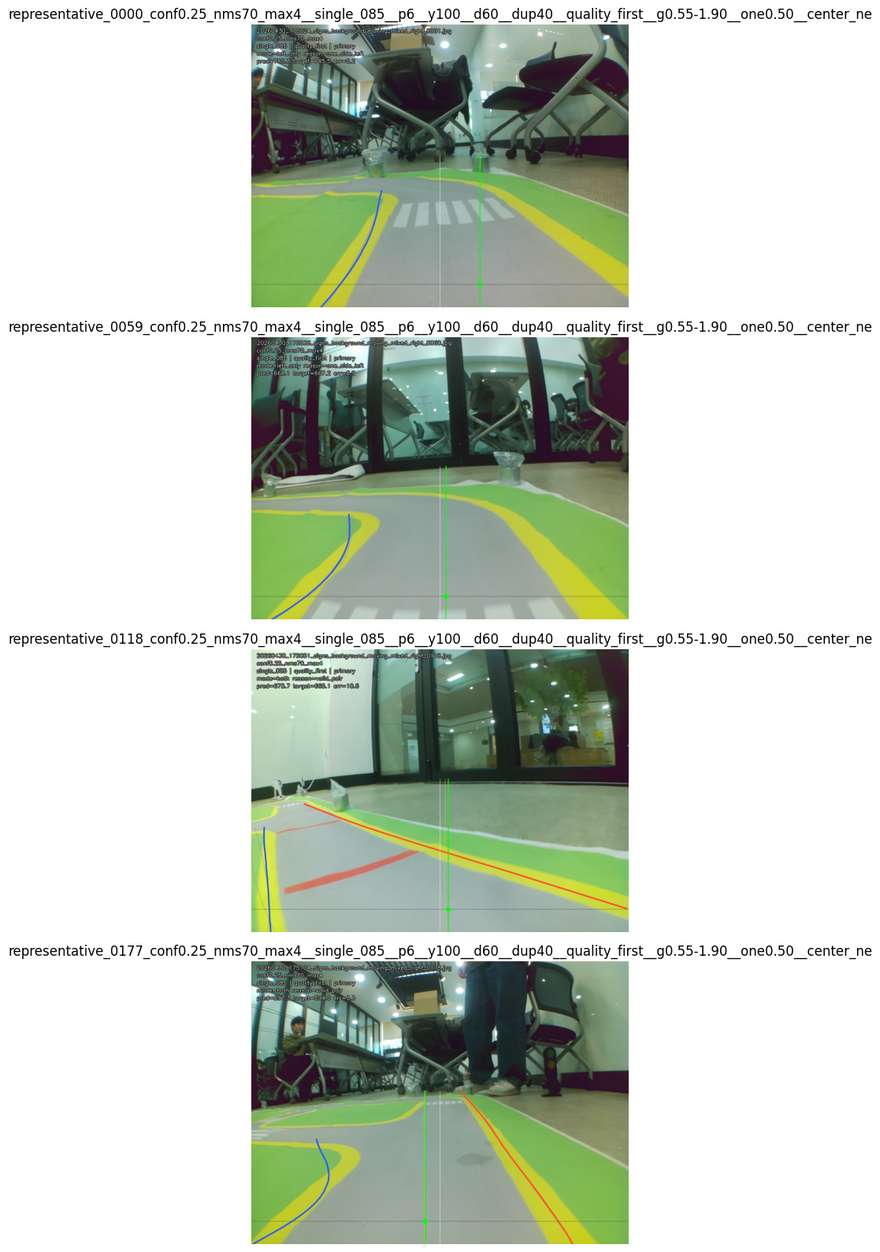

In [44]:
# 대표 샘플 + hard sample overlay 저장.
best_cfg = top_configs[0]
print('best_cfg:', best_cfg)

sample_df = pd.DataFrame([{'index': s['index'], 'scene': s['scene'], 'rel': s['rel']} for s in samples])
representative_indices = []
for scene, group in sample_df.groupby('scene'):
    group = group.sort_values('rel').reset_index(drop=True)
    idx = np.linspace(0, len(group) - 1, min(8, len(group))).round().astype(int)
    representative_indices.extend(group.iloc[idx]['index'].astype(int).tolist())

best_detail = top_detail_df[top_detail_df['config_name'] == best_cfg.name].copy()
hard_indices = (
    best_detail.sort_values(['abs_center_error_px', 'confidence'], ascending=[False, True])
    .head(12)['sample_index'].astype(int).tolist()
)

overlay_rows = []
for tag, indices in [('representative', representative_indices), ('hard', hard_indices)]:
    for idx in indices:
        sample = next(s for s in samples if s['index'] == idx)
        out_path = OVERLAY_DIR / f'{tag}_{idx:04d}_{best_cfg.name[:120]}.png'
        vis, result, target = draw_drive_overlay(sample, best_cfg, out_path)
        overlay_rows.append({
            'tag': tag,
            'sample_index': idx,
            'scene': sample['scene'],
            'file': Path(sample['rel']).name,
            'mode': result['mode'],
            'center_x': result['center_x'],
            'target_center_x': target['center_x'],
            'abs_center_error_px': abs_center_error(result, target),
            'overlay': str(out_path),
        })

overlay_df = pd.DataFrame(overlay_rows)
OVERLAY_INDEX_CSV = TABLE_DIR / 'best_config_overlay_index.csv'
overlay_df.to_csv(win_long_path(OVERLAY_INDEX_CSV), index=False, encoding='utf-8-sig')
display(overlay_df.head(30))

show_paths = overlay_df.head(4)['overlay'].tolist()
fig, axes = plt.subplots(len(show_paths), 1, figsize=(12, 4 * len(show_paths)))
if len(show_paths) == 1:
    axes = [axes]
for ax, path in zip(axes, show_paths):
    img = cv2.cvtColor(cv2_imread_color(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(Path(path).name[:120])
plt.tight_layout()
plt.show()

## 14. Temporal smoothing sweep

04에서는 단순 EMA smoothing이 오히려 악화되었음.  
이번에는 상위 single-frame 설정 몇 개에 대해 temporal 정책을 따로 비교함.

중요:

- temporal은 single-frame postprocess가 어느 정도 안정된 뒤 붙여야 함.
- smoothing이 강하면 직선에서는 부드러워지지만, 코너에서 반응이 늦어질 수 있음.

In [45]:
@dataclass(frozen=True)
class TemporalConfig:
    alpha: float
    max_lost_hold_frames: int
    max_delta_px: float | None

    @property
    def name(self):
        delta = 'none' if self.max_delta_px is None else int(self.max_delta_px)
        return f'alpha{self.alpha:.2f}_hold{self.max_lost_hold_frames}_delta{delta}'


TEMPORAL_CONFIGS = [
    TemporalConfig(alpha, hold, delta)
    for alpha in [0.55, 0.70, 0.85, 1.00]
    for hold in [0, 2, 4]
    for delta in [None, 80.0, 140.0]
]


def temporal_smooth_frame_df(frame_df, tcfg: TemporalConfig):
    parts = []
    for scene, group in frame_df.sort_values(['scene', 'file']).groupby('scene'):
        rows = []
        last_center = np.nan
        lost_count = 0
        for _, row in group.iterrows():
            cur = row['pred_center_x']
            conf = row['confidence']
            out = row.to_dict()
            if np.isfinite(cur):
                proposed = cur
                if np.isfinite(last_center):
                    if tcfg.max_delta_px is not None:
                        proposed = float(np.clip(proposed, last_center - tcfg.max_delta_px, last_center + tcfg.max_delta_px))
                    smooth = tcfg.alpha * proposed + (1 - tcfg.alpha) * last_center
                else:
                    smooth = proposed
                last_center = smooth
                lost_count = 0
                mode = row['pred_mode']
                reason = 'detected_temporal'
                tconf = conf
            else:
                lost_count += 1
                if np.isfinite(last_center) and lost_count <= tcfg.max_lost_hold_frames:
                    smooth = last_center
                    mode = 'hold_lost'
                    reason = f'hold_{lost_count}'
                    tconf = max(0.0, 0.35 * (1 - lost_count / (tcfg.max_lost_hold_frames + 1)))
                else:
                    smooth = np.nan
                    mode = 'lost'
                    reason = 'lost'
                    tconf = 0.0

            out['temporal_center_x'] = smooth
            out['temporal_abs_center_error_px'] = abs(smooth - row['target_center_x']) if np.isfinite(smooth) and np.isfinite(row['target_center_x']) else np.nan
            out['temporal_mode'] = mode
            out['temporal_confidence'] = tconf
            out['temporal_reason'] = reason
            rows.append(out)
        parts.append(pd.DataFrame(rows))
    return pd.concat(parts, ignore_index=True)


def temporal_summary(df, cfg_name, tcfg):
    vals = df['temporal_abs_center_error_px'].dropna().to_numpy(dtype=np.float32)
    lost = int((df['temporal_mode'] == 'lost').sum())
    bad150 = int(np.sum(vals > 150)) if len(vals) else 0
    median = float(np.nanmedian(vals)) if len(vals) else np.nan
    p90 = float(np.nanquantile(vals, 0.90)) if len(vals) else np.nan
    score = median + 0.55 * p90 + 70 * (lost / len(df)) + 45 * (bad150 / max(len(vals), 1))
    return {
        'base_config_name': cfg_name,
        'temporal_name': tcfg.name,
        'alpha': tcfg.alpha,
        'max_lost_hold_frames': tcfg.max_lost_hold_frames,
        'max_delta_px': tcfg.max_delta_px,
        'frames': len(df),
        'valid_center_frames': len(vals),
        'lost_frames': lost,
        'median_abs_center_error_px': median,
        'p90_abs_center_error_px': p90,
        'bad150_frames': bad150,
        'score': float(score),
    }


temporal_rows = []
temporal_detail_parts = []
for cfg_obj in top_configs[:TOP_TEMPORAL_BASE_CONFIGS]:
    _, base_detail = evaluate_config(cfg_obj, save_detail=True)
    base_detail = base_detail.rename(columns={
        'pred_mode': 'pred_mode',
        'pred_center_x': 'pred_center_x',
    })
    for tcfg in TEMPORAL_CONFIGS:
        tdf = temporal_smooth_frame_df(base_detail, tcfg)
        temporal_rows.append(temporal_summary(tdf, cfg_obj.name, tcfg))
        if len(temporal_rows) <= 5:
            temporal_detail_parts.append(tdf.assign(temporal_name=tcfg.name, base_config_name=cfg_obj.name))

temporal_df = pd.DataFrame(temporal_rows).sort_values(
    ['score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'lost_frames'],
    ascending=[True, True, True, True],
).reset_index(drop=True)

TEMPORAL_SWEEP_CSV = TABLE_DIR / 'stage3_temporal_sweep.csv'
temporal_df.to_csv(win_long_path(TEMPORAL_SWEEP_CSV), index=False, encoding='utf-8-sig')
display(temporal_df.head(30))
print('saved:', TEMPORAL_SWEEP_CSV)

,base_config_name,temporal_name,alpha,max_lost_hold_frames,max_delta_px,frames,valid_center_frames,lost_frames,median_abs_center_error_px,p90_abs_center_error_px,bad150_frames,score
0,conf0.20_nms70_max4__single_085__p4__y100__d60...,alpha1.00_hold4_deltanone,1.00,4,NaN,722,669,14,6.204633,54.756760,13,38.552631
1,conf0.25_nms70_max4__single_085__p6__y100__d60...,alpha1.00_hold0_deltanone,1.00,0,NaN,722,648,60,5.928725,48.810795,8,39.147392
2,conf0.25_nms70_max4__single_085__p6__y100__d60...,alpha1.00_hold0_deltanone,1.00,0,NaN,722,648,60,5.928725,48.810795,8,39.147392
3,conf0.20_nms70_max4__single_085__p4__y100__d60...,alpha1.00_hold2_deltanone,1.00,2,NaN,722,667,27,6.184669,53.890316,11,39.184201
4,conf0.20_nms70_max4__single_085__p4__y100__d60...,alpha1.00_hold0_deltanone,1.00,0,NaN,722,653,55,6.015379,49.641697,8,39.202024
5,conf0.25_nms50_max4__single_085__p6__y70__d60_...,alpha1.00_hold0_deltanone,1.00,0,NaN,722,648,60,5.902422,49.521606,9,39.581480
6,conf0.20_nms30_max4__single_085__p8__y100__d60...,alpha1.00_hold0_deltanone,1.00,0,NaN,722,649,62,5.998957,49.725597,8,39.913815
7,conf0.25_nms70_max4__single_085__p6__y100__d60...,alpha1.00_hold4_deltanone,1.00,4,NaN,722,669,14,6.143363,57.349552,15,40.051926
8,conf0.25_nms70_max4__single_085__p6__y100__d60...,alpha1.00_hold4_deltanone,1.00,4,NaN,722,669,14,6.143363,57.349552,15,40.051926
9,conf0.20_nms30_max4__single_085__p8__y100__d60...,alpha1.00_hold4_deltanone,1.00,4,NaN,722,669,17,6.204633,56.980774,14,40.133962


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\tables\stage3_temporal_sweep.csv


## 15. 최종 후보 요약

이 셀은 sweep 결과를 바탕으로 Pi에 옮길 후보를 정리하기 위한 곳임.

후보를 하나만 고집하지 않고, 현장 테스트용으로 두 개 정도 남기는 것이 좋음.

```text
candidate A: 안정/보수형
candidate B: recall/곡선 대응형
```

In [46]:
best_single = post_df.iloc[0].to_dict()
best_temporal = temporal_df.iloc[0].to_dict()

print('BEST SINGLE-FRAME CONFIG')
for k in PostprocessConfig.__dataclass_fields__.keys():
    print(f'{k}: {best_single[k]}')
print('score:', best_single['score'])
print('median:', best_single['median_abs_center_error_px'], 'p90:', best_single['p90_abs_center_error_px'], 'lost:', best_single['lost_frames'])

print('\nBEST TEMPORAL CONFIG')
for k in ['base_config_name', 'temporal_name', 'alpha', 'max_lost_hold_frames', 'max_delta_px', 'score', 'median_abs_center_error_px', 'p90_abs_center_error_px', 'lost_frames']:
    print(f'{k}: {best_temporal[k]}')


def clean_json_value(value):
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, dict):
        return {k: clean_json_value(v) for k, v in value.items()}
    if isinstance(value, list):
        return [clean_json_value(v) for v in value]
    return value


final_candidates = {
    'search_strategy': {
        'type': 'staged',
        'coarse_sample_frames': len(COARSE_SAMPLE_INDICES),
        'coarse_configs': int(len(coarse_df)),
        'full_refined_configs': int(len(post_df)),
        'temporal_configs': int(len(temporal_df)),
    },
    'best_single_frame': {k: best_single[k] for k in PostprocessConfig.__dataclass_fields__.keys()},
    'best_single_frame_metrics': {
        'score': best_single['score'],
        'median_abs_center_error_px': best_single['median_abs_center_error_px'],
        'p90_abs_center_error_px': best_single['p90_abs_center_error_px'],
        'p95_abs_center_error_px': best_single['p95_abs_center_error_px'],
        'lost_frames': int(best_single['lost_frames']),
        'bad100_frames': int(best_single.get('bad100_frames', 0)),
        'bad150_frames': int(best_single['bad150_frames']),
    },
    'best_temporal': {k: best_temporal[k] for k in ['base_config_name', 'temporal_name', 'alpha', 'max_lost_hold_frames', 'max_delta_px']},
    'note': 'overlay 확인 후 Pi 포팅 후보를 최종 선택해야 함',
}
final_candidates = clean_json_value(final_candidates)

FINAL_JSON = TABLE_DIR / 'final_driving_postprocess_candidates.json'
FINAL_JSON.write_text(json.dumps(final_candidates, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
print('saved:', FINAL_JSON)
final_candidates

BEST SINGLE-FRAME CONFIG
detector_name: conf0.25_nms70_max4
lookahead_profile: single_085
min_lane_points: 6
min_y_span: 100.0
max_y_distance: 60.0
duplicate_x_px: 40.0
pair_policy: quality_first
gap_min_scale: 0.55
gap_max_scale: 1.9
one_lane_offset_scale: 0.5
one_lane_policy: center_nearest
center_policy: primary
score: 58.40162996344493
median: 5.928725242614746 p90: 48.810794830322266 lost: 60

BEST TEMPORAL CONFIG
base_config_name: conf0.20_nms70_max4__single_085__p4__y100__d60__dup40__gap_prior__g0.55-1.60__one0.50__center_nearest__primary
temporal_name: alpha1.00_hold4_deltanone
alpha: 1.0
max_lost_hold_frames: 4
max_delta_px: nan
score: 38.55263122199149
median_abs_center_error_px: 6.2046332359313965
p90_abs_center_error_px: 54.75675964355469
lost_frames: 14
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\05_driving_postprocess_sweep\tables\final_driving_postprocess_candidates.json


{'search_strategy': {'type': 'staged',
  'coarse_sample_frames': 240,
  'coarse_configs': 1648,
  'full_refined_configs': 120,
  'temporal_configs': 180},
 'best_single_frame': {'detector_name': 'conf0.25_nms70_max4',
  'lookahead_profile': 'single_085',
  'min_lane_points': 6,
  'min_y_span': 100.0,
  'max_y_distance': 60.0,
  'duplicate_x_px': 40.0,
  'pair_policy': 'quality_first',
  'gap_min_scale': 0.55,
  'gap_max_scale': 1.9,
  'one_lane_offset_scale': 0.5,
  'one_lane_policy': 'center_nearest',
  'center_policy': 'primary'},
 'best_single_frame_metrics': {'score': 58.40162996344493,
  'median_abs_center_error_px': 5.928725242614746,
  'p90_abs_center_error_px': 48.810794830322266,
  'p95_abs_center_error_px': 79.70476531982422,
  'lost_frames': 60,
  'bad100_frames': 24,
  'bad150_frames': 8},
 'best_temporal': {'base_config_name': 'conf0.20_nms70_max4__single_085__p4__y100__d60__dup40__gap_prior__g0.55-1.60__one0.50__center_nearest__primary',
  'temporal_name': 'alpha1.00_hold

## 16. 실행 결과 메모

실행 정상 종료됨. 에러 없음.

이번 노트북은 전수조사 대신 staged sweep으로 실행했음.

- detector sweep: 54개 설정을 전체 holdout 722장 기준으로 평가함.
- coarse postprocess sweep: 1,648개 설정을 scene별 균등 샘플 240장 기준으로 평가함.
- full 검증: coarse 상위 120개 설정만 전체 holdout 722장 기준으로 재평가함.
- temporal sweep: 상위 postprocess 후보 5개 × temporal 설정 36개 = 180개를 평가함.

최종 single-frame 후보:

```text
detector_name: conf0.25_nms70_max4
lookahead_profile: single_085
min_lane_points: 6
min_y_span: 100
max_y_distance: 60
duplicate_x_px: 40
pair_policy: quality_first
gap_min_scale: 0.55
gap_max_scale: 1.90
one_lane_offset_scale: 0.50
one_lane_policy: center_nearest
center_policy: primary
```

전체 holdout 722장 기준 결과:

```text
median_abs_center_error_px: 5.93 px
p90_abs_center_error_px: 48.81 px
p95_abs_center_error_px: 79.70 px
lost_frames: 60 / 722
bad100_frames: 24
bad150_frames: 8
mode counts: both 274, left_only 237, right_only 151, lost 60
```

scene별로도 큰 차이는 없었음.

```text
field1_sign_background: median 6.20 px, p90 49.69 px, p95 77.07 px
field2_traffic_background: median 5.25 px, p90 40.40 px, p95 80.91 px
```

해석:

- 04 노트북보다 더 명확하게 `single_085`, `max_lanes=4`, `conf 0.20~0.25` 계열이 좋게 나옴.
- 숫자상으로는 중심선 추정이 꽤 안정적임. 특히 median 6px 수준은 매우 좋음.
- 단, hard overlay에서 한쪽 lane만 보이는 상황의 offset fallback이 크게 틀어지는 사례가 있음.
- 따라서 Pi 포팅 시 이 설정을 1차 후보로 쓰되, `left_only/right_only`에서는 속도를 낮추고 confidence를 낮게 처리해야 함.
- temporal sweep의 1등은 `alpha=1.0`이라 실제 smoothing은 하지 않고, lost frame hold만 적용한 형태임. 즉 지금 결과만 보면 smoothing 자체는 강하게 넣지 않는 편이 나음.

다음 작업:

1. 이 후보를 기준으로 Pi 주행 스크립트에 driving postprocess를 반영함.
2. 실제 map 주행에서 one-lane fallback이 흔들리는지 확인함.
3. 필요하면 one-lane 상황만 별도 튜닝함.
4. 모델 export/ONNX 변환 후 Pi latency와 함께 최종 주행 후보로 확정함.